In [4]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import KFold
import sklearn.linear_model as lm

from utils import Preprocessor, compute_error

seed = 42
np.random.seed(seed)

sns.set_style('darkgrid')
sns.set_theme(font_scale=1.5)


df = pd.read_csv("data/heartDisease.csv")
df = df.drop(labels=["row.names"], axis=1)


<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
/var/folders/3h/hhvlktwj1rzfznpk5wz5w45w0000gn/T/ipykernel_82135/643727294.py:45: SyntaxWarning: invalid escape sequence '\l'
  plt.axvline(x=best_lam, label=f'best $\lambda$ = {round(best_lam,2)}')
/var/folders/3h/hhvlktwj1rzfznpk5wz5w45w0000gn/T/ipykernel_82135/643727294.py:46: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel("Regularization $\lambda$")
100%|██████████| 200/200 [00:17<00:00, 11.55it/s]


Lambda value with lowest average test error: 5.42
num__ldl 		 0.14964294361275723
num__adiposity 		 3.514023603001508
num__sbp 		 0.14768098283992456
num__age 		 -0.9635775762308694
num__typea 		 0.3813138781960099
num__alcohol 		 0.07297696218777043
num__tobacco 		 -0.003369350179671688
cat__famhist 		 0.16353062034556776
cat__chd 		 -0.4845061085348025


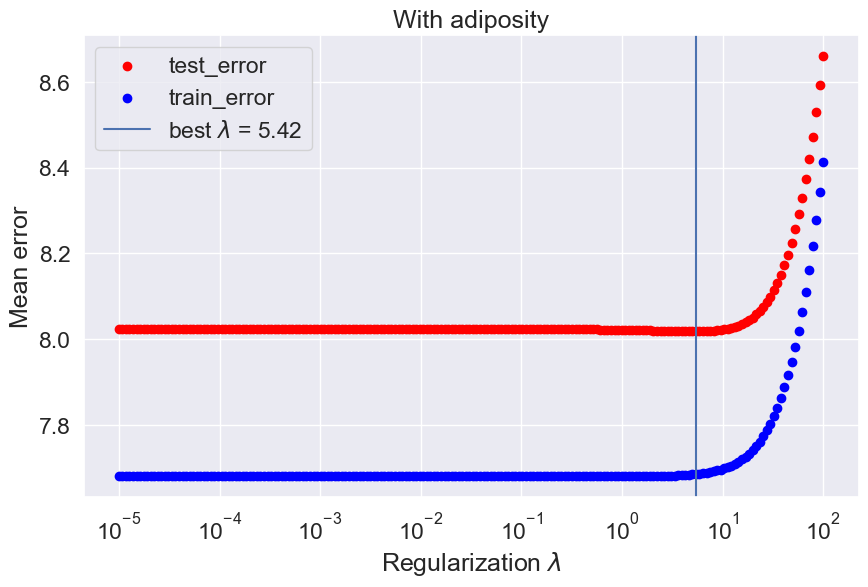

In [5]:
kf = KFold(n_splits=10,shuffle=True, random_state=seed)

lams = np.logspace(np.log10(1e-5), np.log10(1e2), num=200)

train_error_avgs = []
test_error_avgs = []

for lam in tqdm(lams):
    linear_regression_regularized = lm.Ridge(alpha=lam)

    kfold_train_errors = []
    kfold_test_errors = []

    for i, (train_index, test_index) in enumerate(kf.split(df)):
        preprocessor = Preprocessor(task="regression")
        n_train = len(train_index)
        n_test = len(test_index)
        
        df_fold_train = df.iloc[train_index]
        df_fold_test = df.iloc[test_index]

        X_fold_train, y_fold_train = preprocessor.fit_transform(df_fold_train)
        X_fold_test, y_fold_test = preprocessor.transform(df_fold_test)

        linear_regression_regularized.fit(X_fold_train, y_fold_train)
        y_train_hat = linear_regression_regularized.predict(X_fold_train)
        y_test_hat = linear_regression_regularized.predict(X_fold_test)
    
        train_error = compute_error(y_true=y_fold_train, y_pred=y_train_hat)
        test_error = compute_error(y_true=y_fold_test, y_pred=y_test_hat)

        kfold_train_errors.append(train_error)
        kfold_test_errors.append(test_error)

    train_error_avgs.append(np.average(kfold_train_errors))
    test_error_avgs.append(np.average(kfold_test_errors))


best_lam = lams[np.argmin(test_error_avgs)]

fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(lams, test_error_avgs, c='red', label = 'test_error')
ax.scatter(lams, train_error_avgs, c='blue', label='train_error')
plt.axvline(x=best_lam, label=f'best $\lambda$ = {round(best_lam,2)}')
ax.set_xlabel("Regularization $\lambda$")
ax.set_ylabel("Mean error")
ax.set_xscale('log')
ax.legend()
ax.set_title("With adiposity")

print(f"Lambda value with lowest average test error: {round(best_lam,2)}")

best_lm = lm.Ridge(alpha=best_lam)

preprocessor = Preprocessor(task='regression')

X_preprocessed, y = preprocessor.fit_transform(df)

best_lm.fit(X_preprocessed, y)


for coef, feature_name in zip(best_lm.coef_, preprocessor.get_feature_names_out().tolist()):
    print(feature_name, "\t\t", coef)



# Without adiposity

<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
/var/folders/3h/hhvlktwj1rzfznpk5wz5w45w0000gn/T/ipykernel_82135/3923887881.py:44: SyntaxWarning: invalid escape sequence '\l'
  plt.axvline(x=best_lam, label=f'best $\lambda$ = {round(best_lam,2)}')
/var/folders/3h/hhvlktwj1rzfznpk5wz5w45w0000gn/T/ipykernel_82135/3923887881.py:45: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel("Regularization $\lambda$")
100%|██████████| 200/200 [00:16<00:00, 11.81it/s]


Lambda value with lowest average test error: 39.17
num__ldl 		 1.0392465180872683
num__sbp 		 0.538662874173284
num__age 		 0.7852784424559991
num__typea 		 0.3602747277486272
num__alcohol 		 0.19734725991235305
num__tobacco 		 -0.20150817889476513
cat__famhist 		 0.20883364995051126
cat__chd 		 -0.4015155227247505


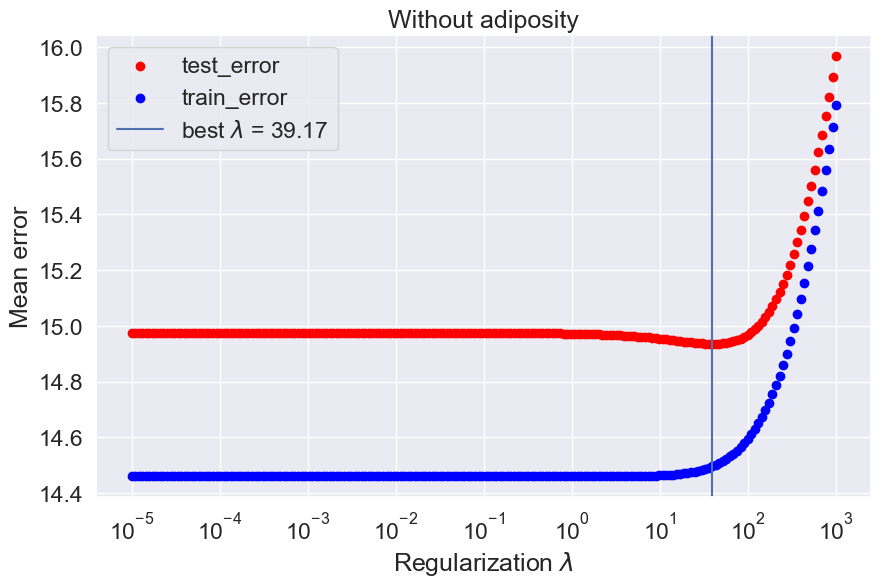

In [6]:
kf = KFold(n_splits=10,shuffle=True, random_state=seed)

lams = np.logspace(np.log10(1e-5), np.log10(1e3), num=200)

train_error_avgs = []
test_error_avgs = []

for lam in tqdm(lams):
    linear_regression_regularized = lm.Ridge(alpha=lam)

    kfold_train_errors = []
    kfold_test_errors = []

    for i, (train_index, test_index) in enumerate(kf.split(df)):
        preprocessor = Preprocessor(task="regression", covariates=["sbp","tobacco","ldl","typea","alcohol","age","chd","famhist"])
        n_train = len(train_index)
        n_test = len(test_index)
        
        df_fold_train = df.iloc[train_index]
        df_fold_test = df.iloc[test_index]

        X_fold_train, y_fold_train = preprocessor.fit_transform(df_fold_train)
        X_fold_test, y_fold_test = preprocessor.transform(df_fold_test)

        linear_regression_regularized.fit(X_fold_train, y_fold_train)
        y_train_hat = linear_regression_regularized.predict(X_fold_train)
        y_test_hat = linear_regression_regularized.predict(X_fold_test)
    
        train_error = compute_error(y_true=y_fold_train, y_pred=y_train_hat)
        test_error = compute_error(y_true=y_fold_test, y_pred=y_test_hat)

        kfold_train_errors.append(train_error)
        kfold_test_errors.append(test_error)

    train_error_avgs.append(np.average(kfold_train_errors))
    test_error_avgs.append(np.average(kfold_test_errors))


best_lam = lams[np.argmin(test_error_avgs)] 
fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(lams, test_error_avgs, c='red', label = 'test_error')
ax.scatter(lams, train_error_avgs, c='blue', label='train_error')
plt.axvline(x=best_lam, label=f'best $\lambda$ = {round(best_lam,2)}')
ax.set_xlabel("Regularization $\lambda$")
ax.set_ylabel("Mean error")
ax.set_xscale('log')
ax.legend()
ax.set_title("Without adiposity")

print(f"Lambda value with lowest average test error: {round(best_lam,2)}")

best_lm = lm.Ridge(alpha=best_lam)

preprocessor = Preprocessor(task="regression", covariates=["sbp","tobacco","ldl","typea","alcohol","age","chd","famhist"])
X_preprocessed, y = preprocessor.fit_transform(df)

best_lm.fit(X_preprocessed, y)


for coef, feature_name in zip(best_lm.coef_, preprocessor.get_feature_names_out().tolist()):
    print(feature_name, "\t\t", coef)


